# Python Object-Oriented Programming (OOP)

**Object-oriented programming** organizes code around **objects** — bundles of DATA (attributes) and CODE (methods/behavior) treated as one unit. An object like a `Car` might have attributes `name`, `price`, `color` and behavior `brake()`, `accelerate()`.

This notebook is an overview tour of the whole OOP toolkit: classes and objects, constructors, encapsulation, polymorphism, and inheritance — each covered at introductory depth here, with dedicated deep-dive notebooks for inheritance and exceptions elsewhere in this series.

## Classes and Objects

A **class** is a blueprint — it defines what attributes and methods every object built from it will have, without itself being a concrete 'thing'. An **object** is an actual INSTANCE built from that blueprint — the real, concrete thing with its own specific attribute values.

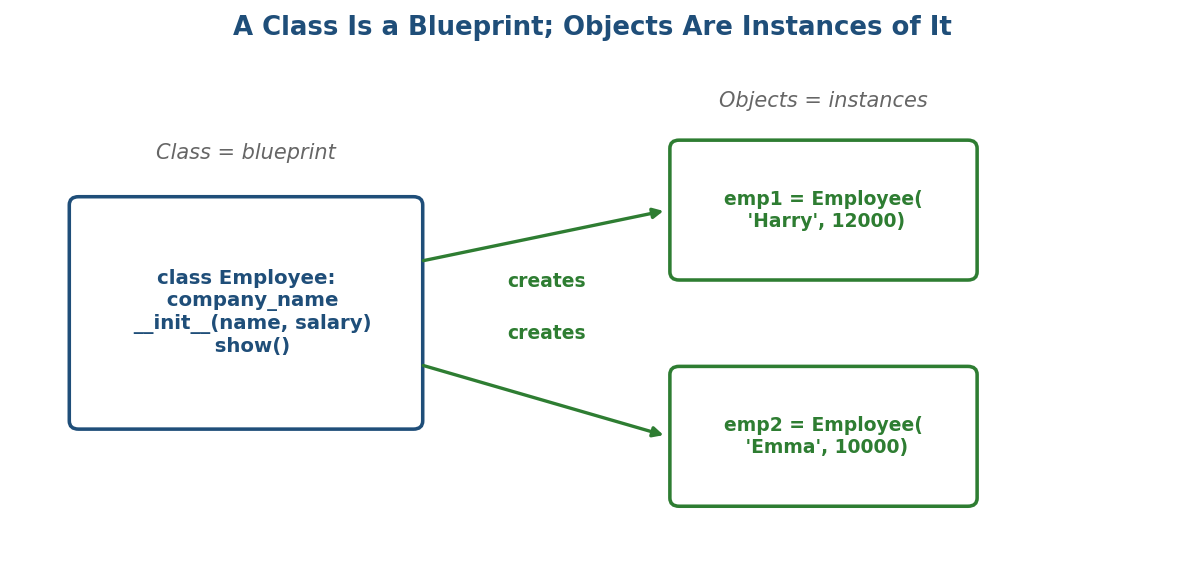

In [ ]:
class Employee:

    # class variable - shared by ALL objects of this class

    company_name = 'ABC Company'



    # constructor - initializes each new object

    def __init__(self, name, salary):

        # instance variables - unique to EACH object

        self.name = name

        self.salary = salary



    # instance method

    def show(self):

        print('Employee:', self.name, self.salary, self.company_name)



emp1 = Employee("Harry", 12000)

emp1.show()



emp2 = Employee("Emma", 10000)

emp2.show()

- `Employee` is the class — the blueprint.
- `emp1` and `emp2` are two SEPARATE objects (instances) built from it — each with its own `name` and `salary`.
- `company_name` is a CLASS variable — shared identically by every object, unless a specific object overrides it.
- `self` in every method refers to the SPECIFIC object the method was called on — it's how `show()` knows whether it's describing `emp1` or `emp2`.

### Class Variables vs. Instance Variables

- **Instance variables** — defined inside `__init__` (or any method) as `self.attribute`; unique to each object.
- **Class variables** — defined directly inside the class body, outside any method; SHARED across every instance unless an individual object explicitly overrides it.

In [ ]:
class Counter:

    total_created = 0   # class variable



    def __init__(self):

        Counter.total_created += 1

        self.my_id = Counter.total_created   # instance variable



a = Counter()

b = Counter()

c = Counter()



print(a.my_id, b.my_id, c.my_id)

print("Total created:", Counter.total_created)

### Instance, Class, and Static Methods

| Method type | Uses | Declared with |
|---|---|---|
| Instance method | instance (`self`) variables | plain `def method(self, ...)` |
| Class method | class variables only | `@classmethod` + `cls` as first parameter |
| Static method | neither — a plain utility function that just happens to live inside the class | `@staticmethod`, no `self`/`cls` |

In [ ]:
class MathHelper:

    pi_approx = 3.14159



    def __init__(self, radius):

        self.radius = radius   # instance variable



    def area(self):   # instance method - uses self.radius

        return MathHelper.pi_approx * self.radius ** 2



    @classmethod

    def describe(cls):   # class method - uses only the class variable

        return f"Uses pi \u2248 {cls.pi_approx}"



    @staticmethod

    def is_positive(n):   # static method - a plain utility, no self/cls needed

        return n > 0



m = MathHelper(5)

print(m.area())

print(MathHelper.describe())

print(MathHelper.is_positive(-3))

## Constructors

A **constructor** initializes a newly-created object — in Python, the `__init__` method. It runs automatically, exactly once, right when the object is created. Every class technically has a constructor; if you don't define one, Python quietly uses a default empty one.

In [ ]:
class Point:

    def __init__(self, x, y):

        self.x = x

        self.y = y



p1 = Point(3, 4)

p2 = Point(0, 0)

print(p1.x, p1.y)

print(p2.x, p2.y)

## Encapsulation

**Encapsulation** bundles data and the methods that operate on it into one unit (the class), and optionally RESTRICTS direct outside access to some of that data — protecting it from accidental or unauthorized changes.

Python has no true `private`/`protected`/`public` keywords like some other languages, but achieves the same effect by CONVENTION:
- No leading underscore — fully public, freely accessible.
- Single leading underscore (`_name`) — 'protected' by convention only; still technically accessible, but signals 'internal use, please don't touch directly.'
- Double leading underscore (`__name`) — triggers **name mangling**, making it genuinely awkward (though not impossible) to access from outside the class.

In [ ]:
class Employee:

    def __init__(self, name, salary):

        self.name = name          # public

        self.__salary = salary    # 'private' (name-mangled)



    def show(self):

        print("Name is", self.name, "and salary is", self.__salary)



emp = Employee("Jessa", 40000)

emp.show()



try:

    print(emp.__salary)

except AttributeError as e:

    print("AttributeError:", e)

**How name mangling actually works:** `self.__salary` inside the class is silently rewritten by Python to `self._Employee__salary`. It's not truly unreachable from outside — `emp._Employee__salary` WOULD work — but this awkward, class-specific name makes accidental external access highly unlikely, which is the whole point.

In [ ]:
emp = Employee("Jessa", 40000)

print(emp._Employee__salary)   # technically works, but nobody should rely on this

## Polymorphism

**Polymorphism** ('many forms') means the SAME action/method name behaves differently depending on the object it's called on. Two entirely unrelated classes can both define a method with the identical name, and code written generically against 'anything with that method' works for both, without caring which specific class it actually received.

In [ ]:
class Circle:

    pi = 3.14



    def __init__(self, radius):

        self.radius = radius



    def calculate_area(self):

        print("Area of circle:", self.pi * self.radius * self.radius)



class Rectangle:

    def __init__(self, length, width):

        self.length = length

        self.width = width



    def calculate_area(self):

        print("Area of Rectangle:", self.length * self.width)



def area(shape):

    # this function doesn't know or care whether 'shape' is a Circle or Rectangle -

    # it just calls calculate_area() and trusts polymorphism to do the right thing

    shape.calculate_area()



cir = Circle(5)

rect = Rectangle(10, 5)



area(cir)

area(rect)

## Inheritance

**Inheritance** lets a new class (the CHILD or DERIVED class) reuse the attributes and methods of an existing class (the PARENT or BASE class) — the primary tool for code reuse in OOP. The child automatically gets everything the parent has, and can ADD new attributes/methods or OVERRIDE existing ones.

```
class BaseClass:
    # body of base class

class DerivedClass(BaseClass):
    # body of derived class
```

In [ ]:
class Vehicle:

    def __init__(self, name, color, price):

        self.name = name

        self.color = color

        self.price = price



    def info(self):

        print(self.name, self.color, self.price)



class Car(Vehicle):

    def change_gear(self, no):

        print(self.name, 'change gear to number', no)



car = Car('BMW X1', 'Black', 35000)

car.info()            # inherited from Vehicle - Car never defined this itself

car.change_gear(5)    # defined directly on Car

`Car` never defines `__init__` or `info()` itself — it inherits both directly from `Vehicle`, and only adds the ONE thing genuinely specific to cars: `change_gear()`. This is the DRY principle in action: the shared logic lives in exactly one place. A deeper dive into inheritance types, method overriding, and `super()` follows in the dedicated Inheritance notebook next in this series.

## Summary

- **Class** = blueprint; **object** = a concrete instance built from it.
- **Instance variables** are unique per object (`self.x`); **class variables** are shared by all objects of that class.
- **Instance methods** use `self`; **class methods** (`@classmethod`, `cls`) use only class-level state; **static methods** (`@staticmethod`) use neither, and are just utility functions grouped inside the class.
- The **constructor** (`__init__`) runs automatically once, right when an object is created, to set up its initial state.
- **Encapsulation** bundles data with its methods and, by convention (`_x`, `__x`), restricts direct outside access.
- **Polymorphism** lets the same method name behave differently across unrelated classes, enabling generic code that works with 'anything that has this method.'
- **Inheritance** lets a child class reuse and extend a parent class's attributes and methods — the core DRY mechanism in OOP.

## Practice Exercises

1. Create a `BankAccount` class with a 'private' `__balance` attribute, plus `deposit(amount)` and `withdraw(amount)` methods that update it safely (reject a withdrawal that would make the balance negative).
2. Add a class variable `total_accounts` to `BankAccount` that increments every time a new account is created, and a class method `get_total_accounts()` to report it.
3. Create two classes `Cat` and `Dog`, each with a `speak()` method returning a different string, then write a function that calls `speak()` on a list containing both, demonstrating polymorphism.
4. Create a base class `Shape` with a method `describe()`, and two subclasses `Square` and `Triangle` that inherit from it and add their own `area()` method.
5. Add a static method `is_valid_amount(amount)` to `BankAccount` that checks whether a number is a valid (positive) transaction amount, and use it inside `deposit()`.

### Exercise 1 solution

In [ ]:
class BankAccount:

    def __init__(self, owner, balance=0):

        self.owner = owner

        self.__balance = balance



    def deposit(self, amount):

        self.__balance += amount

        print(f"Deposited {amount}. New balance: {self.__balance}")



    def withdraw(self, amount):

        if amount > self.__balance:

            print("Insufficient funds.")

        else:

            self.__balance -= amount

            print(f"Withdrew {amount}. New balance: {self.__balance}")



acc = BankAccount("Jessa", 100)

acc.deposit(50)

acc.withdraw(200)

acc.withdraw(100)

### Exercise 2 solution

In [ ]:
class BankAccount:

    total_accounts = 0



    def __init__(self, owner, balance=0):

        self.owner = owner

        self.__balance = balance

        BankAccount.total_accounts += 1



    @classmethod

    def get_total_accounts(cls):

        return cls.total_accounts



a1 = BankAccount("Jessa")

a2 = BankAccount("Emma")

a3 = BankAccount("Kelly")

print(BankAccount.get_total_accounts())

### Exercise 3 solution

In [ ]:
class Cat:

    def speak(self):

        return "Meow!"



class Dog:

    def speak(self):

        return "Woof!"



animals = [Cat(), Dog(), Cat()]

for animal in animals:

    print(animal.speak())

### Exercise 4 solution

In [ ]:
class Shape:

    def describe(self):

        print(f"This is a {type(self).__name__}.")



class Square(Shape):

    def __init__(self, side):

        self.side = side



    def area(self):

        return self.side ** 2



class Triangle(Shape):

    def __init__(self, base, height):

        self.base = base

        self.height = height



    def area(self):

        return 0.5 * self.base * self.height



sq = Square(4)

tri = Triangle(6, 3)



sq.describe()

print("Area:", sq.area())

tri.describe()

print("Area:", tri.area())

### Exercise 5 solution

In [ ]:
class BankAccount:

    def __init__(self, owner, balance=0):

        self.owner = owner

        self.__balance = balance



    @staticmethod

    def is_valid_amount(amount):

        return amount > 0



    def deposit(self, amount):

        if not BankAccount.is_valid_amount(amount):

            print("Invalid deposit amount.")

            return

        self.__balance += amount

        print(f"Deposited {amount}. New balance: {self.__balance}")



acc = BankAccount("Jessa", 100)

acc.deposit(50)

acc.deposit(-20)